# train_offline.ipynb

Interactive version of `train_offline.py` — same model lineup (RLS, RF, LSTM, GRU, ENS), same feature / normalizer / save contract as `live_common.py`.

**Before running:** make sure `live_common.py` and your session CSVs are accessible to the notebook.
- **Local:** run this notebook from the repo root.
- **Colab:** upload `live_common.py` to `/content/`, upload your   `*_emg_raw.csv` + main session `.csv` pair, then set `SESSION_CSVS`   below to those paths.

## 1. Setup

In [ ]:
# Colab one-time install (uncomment if running on a fresh Colab VM):
# !pip install -q scikit-learn scipy numpy torch tqdm

: 

## 1b. Upload files  (`ipywidgets.FileUpload` — works in VSCode Colab)

Unlike `google.colab.files.upload()` (which only works inside a real Colab browser tab), `ipywidgets.FileUpload` works in any Jupyter frontend, including the VSCode Colab extension.

1. Run the next cell.  A small **Upload** button appears.
2. Click it, pick `live_common.py` **and** your session CSV pair    (main `.csv` + matching `_emg_raw.csv`).  Multi-select is on.
3. Run the cell after that to write the uploaded bytes to `/content/`.
4. Update `SESSION_CSVS` in the *Knobs* cell to point at the uploaded    filenames.

If you're running locally (not on a Colab VM), skip both cells — the files are already on disk.

In [3]:
import os

try:
    from google.colab import drive as _d   # presence check only
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not on Colab — skipping upload. Run from repo root locally.')

if IN_COLAB:
    try:
        import ipywidgets as widgets
        from IPython.display import display
    except ImportError:
        raise RuntimeError('ipywidgets missing. Install with !pip install -q ipywidgets')

    os.chdir('/content')
    uploader = widgets.FileUpload(accept='', multiple=True)
    display(uploader)
    print('Pick live_common.py + your session CSVs, then run the next cell.')

FileUpload(value={}, description='Upload', multiple=True)

Pick live_common.py + your session CSVs, then run the next cell.


: 

In [18]:
# Run this AFTER picking files in the uploader above.
if IN_COLAB:
    value = uploader.value
    if not value:
        print('Nothing uploaded yet — click the Upload button in the widget above first.')
    else:
        def _iter(v):
            if isinstance(v, dict):           # ipywidgets v7
                for name, meta in v.items():
                    yield name, bytes(meta['content'])
            else:                             # ipywidgets v8 (tuple of dicts)
                for item in v:
                    yield item['name'], bytes(item['content'])

        for name, content in _iter(value):
            with open(name, 'wb') as f:
                f.write(content)
            print(f'  saved: {name}  ({len(content):,} bytes)')
        print(f'\ncwd = {os.getcwd()}')
        print('Files now in /content/:')
        for f in sorted(os.listdir('/content')):
            if not f.startswith('.'): print(' ', f)

  saved: arsh_live_train_20260622_182226.csv  (1,510,634 bytes)

cwd = /content
Files now in /content/:
  __pycache__
  arsh_live_train_20260622_182226.csv
  arsh_live_train_20260622_182226_emg_raw.csv
  live_common.py
  sample_data


In [19]:
import os, csv, time
from datetime import datetime
import numpy as np
from tqdm.auto import tqdm

import live_common as lc
from live_common import (
    Normalizers, features_from_arr, make_models, save_bundle,
    set_active_norms, HAS_TORCH,
    N_CH, EMG_WINDOW, PRED_HORIZON_S, SEQ_BATCH,
    RLSModel, RFModel,
)
if HAS_TORCH:
    import torch

print(f'torch available: {HAS_TORCH}, EMG_WINDOW={EMG_WINDOW}, N_CH={N_CH}')

torch available: True, EMG_WINDOW=75, N_CH=4


## 2. Knobs

In [20]:
# Edit these for your run.
SESSION_CSVS = [
    'arsh_live_train_20260622_182226.csv',
    # add more session CSVs here
]
HORIZON     = 0.15      # seconds — predict angle this far in the future
EPOCHS      = 30        # for LSTM/GRU
VAL_FRAC    = 0.2       # last N% of each session held out for validation
TOL_S       = 0.05      # max |t_window+H - t_angle| to accept a pair
STEP        = 1         # window stride in samples (1 = every sample)
INCLUDE_SEQ = HAS_TORCH # set False to skip LSTM/GRU even if torch is installed
OUT_BUNDLE  = None      # path to save bundle; None = auto models/bundle_offline_<TS>.pkl

## 3. Pick device (CUDA / MPS / CPU)

In [21]:
def pick_device():
    if not HAS_TORCH:
        return None
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = pick_device()
if HAS_TORCH and DEVICE.type == 'cpu':
    torch.set_num_threads(max(1, os.cpu_count() or 1))
print(f'Device: {DEVICE}  (torch threads: {torch.get_num_threads() if HAS_TORCH else 0})')

Device: cuda  (torch threads: 1)


## 4. Load sessions

Each main CSV's matching `_emg_raw.csv` is found automatically.

In [22]:
def _raw_path_for(main_csv):
    base, ext = os.path.splitext(main_csv)
    p = f'{base}_emg_raw{ext}'
    if not os.path.exists(p):
        raise FileNotFoundError(f'matching raw CSV not found: {p}')
    return p

def _iso_to_unix(s):
    try:    return datetime.fromisoformat(s).timestamp()
    except: return None

def load_session(main_csv):
    raw_csv = _raw_path_for(main_csv)
    print(f'  raw: {raw_csv}')
    samples = []
    with open(raw_csv) as f:
        for row in csv.DictReader(f):
            try:
                samples.append((float(row['t_mono']),
                                float(row['m1']), float(row['m2']),
                                float(row['m3']), float(row['grav_env'])))
            except (ValueError, KeyError):
                continue
    samples = np.array(samples, dtype=float)
    print(f'  raw samples: {len(samples)}')

    angles = []
    with open(main_csv) as f:
        reader = csv.DictReader(f)
        has_t = 't_mono' in (reader.fieldnames or [])
        for row in reader:
            try:
                ang = row.get('angle_deg')
                if ang in (None, ''):  continue
                ang = float(ang)
                if not np.isfinite(ang):  continue
                t = float(row['t_mono']) if (has_t and row.get('t_mono')) \
                    else _iso_to_unix(row['timestamp'])
                if t is None:  continue
                angles.append((t, ang))
            except (ValueError, KeyError):
                continue
    angles = np.array(angles, dtype=float)
    print(f'  angles: {len(angles)}')
    return samples, angles

loaded = []
for sess in SESSION_CSVS:
    print(f'Loading: {sess}')
    samples, angles = load_session(sess)
    if len(samples) < EMG_WINDOW or len(angles) == 0:
        print('  (skipping)')
        continue
    loaded.append((samples, angles))
assert loaded, 'No usable sessions.'

Loading: arsh_live_train_20260622_182226.csv
  raw: arsh_live_train_20260622_182226_emg_raw.csv
  raw samples: 32097
  angles: 7108


## 5. Build (window, label) pairs at the chosen horizon

In [23]:
def build_pairs(samples, angles, horizon_s, tol_s=0.05, step=1):
    if len(samples) < EMG_WINDOW or len(angles) == 0:
        return (np.zeros((0, 4*N_CH)),
                np.zeros((0, EMG_WINDOW, N_CH)), np.zeros(0))
    angles = angles[angles[:, 0].argsort()]
    ang_ts = angles[:, 0]
    feats, raws, ys = [], [], []
    ends = range(EMG_WINDOW, len(samples) + 1, step)
    for end in tqdm(ends, desc='pairing', unit='win', leave=False):
        win = samples[end - EMG_WINDOW:end]
        t_end = float(win[-1, 0])
        target_t = t_end + horizon_s
        idx = np.searchsorted(ang_ts, target_t)
        cand = []
        if idx > 0:           cand.append(idx - 1)
        if idx < len(ang_ts): cand.append(idx)
        if not cand:  continue
        best = min(cand, key=lambda j: abs(ang_ts[j] - target_t))
        if abs(ang_ts[best] - target_t) > tol_s:  continue
        feats.append(features_from_arr(win))
        raws.append(win[:, 1:1 + N_CH].copy())
        ys.append(float(angles[best, 1]))
    return (np.array(feats, dtype=float),
            np.array(raws, dtype=float),
            np.array(ys, dtype=float))

per_sess = []
for samples, angles in loaded:
    f, r, y = build_pairs(samples, angles, horizon_s=HORIZON,
                          tol_s=TOL_S, step=STEP)
    print(f'  pairs: {len(y)}  y in [{y.min():.1f}, {y.max():.1f}]'
          f'  mean={y.mean():.1f}' if len(y) else '  no pairs')
    if len(f) > 0:
        per_sess.append((f, r, y))
assert per_sess, 'No usable pairs.'

pairing:   0%|          | 0/32023 [00:00<?, ?win/s]

  pairs: 30102  y in [26.9, 174.7]  mean=128.2


## 6. Temporal train/val split  (last `VAL_FRAC` of each session)

In [24]:
def temporal_split(per_sess, val_frac):
    tr_f, tr_r, tr_y = [], [], []
    va_f, va_r, va_y = [], [], []
    for f, r, y in per_sess:
        n = len(y)
        n_val = min(max(1, int(n * val_frac)), n - 1) if n >= 2 else 0
        if n_val == 0:
            tr_f.append(f); tr_r.append(r); tr_y.append(y)
            continue
        tr_f.append(f[:-n_val]); tr_r.append(r[:-n_val]); tr_y.append(y[:-n_val])
        va_f.append(f[-n_val:]); va_r.append(r[-n_val:]); va_y.append(y[-n_val:])
    cat = lambda L, default: np.concatenate(L) if L else np.zeros(default)
    return (cat(tr_f, (0, 4*N_CH)), cat(tr_r, (0, EMG_WINDOW, N_CH)), cat(tr_y, (0,)),
            cat(va_f, (0, 4*N_CH)), cat(va_r, (0, EMG_WINDOW, N_CH)), cat(va_y, (0,)))

tr_f, tr_r, tr_y, va_f, va_r, va_y = temporal_split(per_sess, VAL_FRAC)
print(f'train pairs: {len(tr_y)}   val pairs: {len(va_y)}')

train pairs: 24082   val pairs: 6020


## 7. Fit EMA normalizers on the train set, then normalize both splits

In [25]:
norms = Normalizers()
for i in range(len(tr_f)):
    norms.update_feat(tr_f[i])
    norms.update_raw(tr_r[i])
    norms.update_tgt(tr_y[i])
set_active_norms(norms)

tr_xn = np.array([norms.norm_feat(f) for f in tr_f], dtype=np.float32)
tr_rn = np.array([norms.norm_raw(r)  for r in tr_r], dtype=np.float32)
va_xn = (np.array([norms.norm_feat(f) for f in va_f], dtype=np.float32)
         if len(va_f) else np.zeros((0, tr_xn.shape[1]), dtype=np.float32))
va_rn = (np.array([norms.norm_raw(r) for r in va_r], dtype=np.float32)
         if len(va_r) else np.zeros((0,) + tr_rn.shape[1:], dtype=np.float32))
print(f'feat shape: {tr_xn.shape}   raw shape: {tr_rn.shape}')

feat shape: (24082, 16)   raw shape: (24082, 75, 4)


## 8. Build the model set

In [26]:
models, ensemble, display = make_models(include_seq=INCLUDE_SEQ)
rls = next(m for m in models if isinstance(m, RLSModel))
rf  = next(m for m in models if isinstance(m, RFModel))
print('models:', [m.name for m in display])

models: ['RLS', 'RF', 'LSTM', 'GRU', 'ENS']


## 9. Train RLS

In [27]:
print(f'RLS: single pass over {len(tr_xn)} samples')
for i in tqdm(range(len(tr_xn)), desc='RLS', unit='sample'):
    rls.update(tr_xn[i], float(tr_y[i]))

RLS: single pass over 24082 samples


RLS:   0%|          | 0/24082 [00:00<?, ?sample/s]

## 10. Train Random Forest

In [28]:
n = min(len(tr_xn), lc.RF_REPLAY_MAX)
print(f'RF: fit on last {n} samples (cap={lc.RF_REPLAY_MAX}, '
      f'trees={lc.RF_TREES}, depth={lc.RF_MAX_DEPTH})')
rf.fit_now(tr_xn[-n:], tr_y[-n:])
print('RF trained.')

RF: fit on last 1500 samples (cap=1500, trees=120, depth=20)
RF trained.


## 11. Train LSTM and GRU

In [29]:
def train_seq(model, rn, ys, norms, epochs, batch_size=SEQ_BATCH, device=None):
    if not HAS_TORCH:
        print('torch unavailable; skipping', model.name); return
    device = device or torch.device('cpu')
    n = len(rn)
    print(f'{model.name}: {epochs} epochs on {device}, '
          f'hidden={lc.SEQ_HIDDEN} layers={lc.SEQ_LAYERS} batch={batch_size}')
    model.net.to(device)
    model.opt = torch.optim.Adam(model.net.parameters(),
                                 lr=lc.SEQ_LR, weight_decay=lc.SEQ_WD)
    mean, std = norms.t_mean, norms.t_std
    rn_t = torch.from_numpy(rn.astype(np.float32)).to(device)
    ys_t = torch.from_numpy(((ys - mean) / std).astype(np.float32)).to(device)
    bar = tqdm(range(epochs), desc=model.name, unit='ep')
    last = float('nan')
    for ep in bar:
        idx = np.random.permutation(n)
        losses = []
        for s in range(0, n, batch_size):
            b = idx[s:s + batch_size]
            model.opt.zero_grad()
            pred = model.net(rn_t[b])
            loss = model.loss_fn(pred, ys_t[b])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.net.parameters(), 5.0)
            model.opt.step()
            losses.append(loss.item())
        last = float(np.mean(losses))
        bar.set_postfix(loss=f'{last:.4f}')
    bar.close()
    if device.type != 'cpu':
        model.net.to(torch.device('cpu'))
        model.opt = torch.optim.Adam(model.net.parameters(),
                                     lr=lc.SEQ_LR, weight_decay=lc.SEQ_WD)
    model.trained = True
    model.extra = f'loss={last:.3f}'

if INCLUDE_SEQ:
    for m in models:
        if m.kind == 'seq':
            train_seq(m, tr_rn, tr_y, norms, epochs=EPOCHS, device=DEVICE)
else:
    print('Skipped sequence nets (INCLUDE_SEQ=False).')

LSTM: 30 epochs on cuda, hidden=80 layers=3 batch=32


LSTM:   0%|          | 0/30 [00:00<?, ?ep/s]

GRU: 30 epochs on cuda, hidden=80 layers=3 batch=32


GRU:   0%|          | 0/30 [00:00<?, ?ep/s]

## 12. Score every model on train + val   (this is the headline result)

In [30]:
def model_mae(model, xn, rn, ys, desc=''):
    if len(ys) == 0:
        return float('nan')
    preds = []
    for i in tqdm(range(len(ys)), desc=desc, unit='sample', leave=False):
        inp = xn[i] if model.kind == 'feat' else rn[i]
        p = model.predict(inp)
        preds.append(p if p is not None else np.nan)
    preds = np.array(preds)
    v = np.isfinite(preds)
    return float(np.mean(np.abs(preds[v] - ys[v]))) if v.any() else float('nan')

metrics = {}
weight_basis = {}
for m in models:
    tr = model_mae(m, tr_xn, tr_rn, tr_y, desc=f'eval {m.name} (train)')
    va = model_mae(m, va_xn, va_rn, va_y, desc=f'eval {m.name} (val)')
    metrics[m.name] = (tr, va)
    weight_basis[m.name] = (va if np.isfinite(va) else tr)

# pin ensemble blend weights to val MAE
ensemble.static_mae = {k: (v if np.isfinite(v) else 1.0)
                       for k, v in weight_basis.items()}

def ens_mae(xn, rn, ys, desc='eval ENS'):
    if len(ys) == 0: return float('nan')
    preds = []
    for i in tqdm(range(len(ys)), desc=desc, unit='sample', leave=False):
        per = {m.name: m.predict(xn[i] if m.kind == 'feat' else rn[i])
               for m in models}
        preds.append(ensemble.blend(per))
    preds = np.array([p if p is not None else np.nan for p in preds])
    v = np.isfinite(preds)
    return float(np.mean(np.abs(preds[v] - ys[v]))) if v.any() else float('nan')

metrics['ENS'] = (ens_mae(tr_xn, tr_rn, tr_y, desc='eval ENS (train)'),
                  ens_mae(va_xn, va_rn, va_y, desc='eval ENS (val)'))

print()
print(f'{"model":<6}  train MAE     val MAE')
for n, (tr, va) in metrics.items():
    va_s = f'{va:7.2f}°' if np.isfinite(va) else '   --   '
    print(f'{n:<6}  {tr:7.2f}°    {va_s}')
print(f'(n_train={len(tr_y)}, n_val={len(va_y)})')

eval RLS (train):   0%|          | 0/24082 [00:00<?, ?sample/s]

eval RLS (val):   0%|          | 0/6020 [00:00<?, ?sample/s]

eval RF (train):   0%|          | 0/24082 [00:00<?, ?sample/s]

eval RF (val):   0%|          | 0/6020 [00:00<?, ?sample/s]

eval LSTM (train):   0%|          | 0/24082 [00:00<?, ?sample/s]

...

eval GRU (train):   0%|          | 0/24082 [00:00<?, ?sample/s]

eval GRU (val):   0%|          | 0/6020 [00:00<?, ?sample/s]

eval ENS (train):   0%|          | 0/24082 [00:00<?, ?sample/s]

eval ENS (val):   0%|          | 0/6020 [00:00<?, ?sample/s]


model   train MAE     val MAE
RLS       12.38°      11.06°
RF        10.91°      12.34°
LSTM       1.77°       4.84°
GRU        1.94°       4.81°
ENS        3.90°       6.16°
(n_train=24082, n_val=6020)


## 13. Plot predictions vs truth on the validation set  *(optional)*

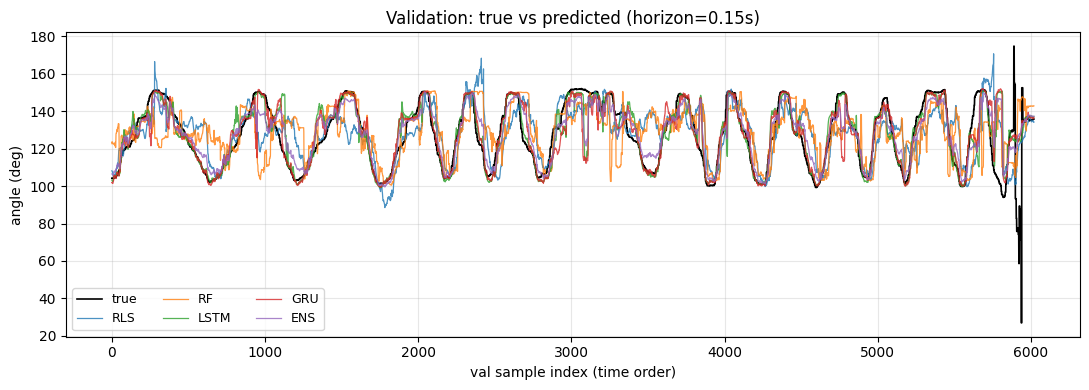

In [31]:
import matplotlib.pyplot as plt

if len(va_y) >= 2:
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(va_y, label='true', color='black', lw=1.2)
    for m in display:
        preds = []
        for i in range(len(va_y)):
            if m.kind == 'ens':
                per = {mm.name: mm.predict(va_xn[i] if mm.kind == 'feat' else va_rn[i])
                       for mm in models}
                p = ensemble.blend(per)
            else:
                inp = va_xn[i] if m.kind == 'feat' else va_rn[i]
                p = m.predict(inp)
            preds.append(p if p is not None else np.nan)
        ax.plot(preds, label=m.name, alpha=0.8, lw=0.9)
    ax.set_xlabel('val sample index (time order)')
    ax.set_ylabel('angle (deg)')
    ax.set_title(f'Validation: true vs predicted (horizon={HORIZON}s)')
    ax.legend(loc='best', ncol=3, fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('No val data to plot.')

## 14. Save the bundle  (loadable by `live_deploy.py`)

In [ ]:
import shutil
from IPython.display import display, FileLink

out_path = OUT_BUNDLE
if out_path is None:
    os.makedirs('models', exist_ok=True)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    out_path = f'models/bundle_offline_{ts}.pkl'

save_bundle(out_path, models, ensemble, norms, extra_meta={
    'trained_offline':     True,
    'trained_in_notebook': True,
    'n_train_pairs': int(len(tr_y)),
    'n_val_pairs':   int(len(va_y)),
    'n_sessions':    len(loaded),
    'epochs':        int(EPOCHS),
    'step':          int(STEP),
    'pred_horizon_s': float(HORIZON),
    'val_frac':      float(VAL_FRAC),
})
print(f'Saved bundle -> {out_path}  ({os.path.getsize(out_path):,} bytes)')

# --- Get the file off the VM ---

# (a) Clickable download link in the notebook output — works in real
#     Colab, Jupyter, and the VSCode notebook UI.  Click it to save
#     the bundle to your laptop.
try:
    display(FileLink(out_path))
except Exception as e:
    print(f'(FileLink unavailable: {e})')

# (b) If running in the real Colab browser, also trigger an auto-download.
#     In the VSCode Colab extension this is usually a no-op; use the link above.
try:
    from google.colab import files as _gcf
    _gcf.download(out_path)
except Exception:
    pass

# (c) If Google Drive is mounted, copy the bundle there too so it survives
#     VM teardown.  (Mount with: from google.colab import drive; drive.mount('/content/drive'))
try:
    if os.path.isdir('/content/drive/MyDrive'):
        drive_dir = '/content/drive/MyDrive/emg_bundles'
        os.makedirs(drive_dir, exist_ok=True)
        dst = os.path.join(drive_dir, os.path.basename(out_path))
        shutil.copy(out_path, dst)
        print(f'Also copied to Drive: {dst}')
except Exception as e:
    print(f'(Drive copy skipped: {e})')

In [ ]:
print("hello")

## 15. (Optional) Horizon sweep — rebuild + retrain at multiple horizons

Useful for finding the horizon that minimizes val MAE.  No bundle is saved from the sweep; pick the winning horizon, set `HORIZON` above, re-run cells 5–14 to train + save.

In [33]:
SWEEP_HORIZONS = [0.05, 0.10, 0.15, 0.20, 0.25]

sweep_results = {}
for h in SWEEP_HORIZONS:
    print(f'\n=== horizon = {h:.3f}s ===')
    ps = []
    for samples, angles in loaded:
        f, r, y = build_pairs(samples, angles, horizon_s=h, tol_s=TOL_S, step=STEP)
        if len(f) > 0:
            ps.append((f, r, y))
    if not ps:
        print('  no pairs at this horizon'); continue
    sf, sr, sy, vf, vr, vy = temporal_split(ps, VAL_FRAC)
    norms_h = Normalizers()
    for i in range(len(sf)):
        norms_h.update_feat(sf[i]); norms_h.update_raw(sr[i]); norms_h.update_tgt(sy[i])
    set_active_norms(norms_h)
    sxn = np.array([norms_h.norm_feat(f) for f in sf], dtype=np.float32)
    srn = np.array([norms_h.norm_raw(r)  for r in sr], dtype=np.float32)
    vxn = np.array([norms_h.norm_feat(f) for f in vf], dtype=np.float32) if len(vf) else np.zeros((0, sxn.shape[1]))
    vrn = np.array([norms_h.norm_raw(r)  for r in vr], dtype=np.float32) if len(vr) else np.zeros((0,) + srn.shape[1:])
    mh, eh, dh = make_models(include_seq=INCLUDE_SEQ)
    rls_h = next(m for m in mh if isinstance(m, RLSModel))
    rf_h  = next(m for m in mh if isinstance(m, RFModel))
    for i in tqdm(range(len(sxn)), desc='RLS', leave=False):
        rls_h.update(sxn[i], float(sy[i]))
    rf_h.fit_now(sxn[-min(len(sxn), lc.RF_REPLAY_MAX):],
                 sy[-min(len(sy),  lc.RF_REPLAY_MAX):])
    if INCLUDE_SEQ:
        for m in mh:
            if m.kind == 'seq':
                train_seq(m, srn, sy, norms_h, epochs=EPOCHS, device=DEVICE)
    row = {m.name: model_mae(m, vxn, vrn, vy, desc=f'  {m.name}') for m in mh}
    sweep_results[h] = row
    for n, v in row.items():
        print(f'  {n:<6} val MAE = {v:6.2f}°')

print('\n=== sweep summary (val MAE) ===')
model_names = [m.name for m in display if m.name != 'ENS']
header = 'horizon  ' + '  '.join(f'{n:<7}' for n in model_names)
print(header)
for h, row in sweep_results.items():
    vals = '  '.join(f'{row.get(n, float("nan")):7.2f}' for n in model_names)
    print(f'{h:7.3f}  {vals}')


=== horizon = 0.050s ===


pairing:   0%|          | 0/32023 [00:00<?, ?win/s]

RLS:   0%|          | 0/24085 [00:00<?, ?it/s]

LSTM: 30 epochs on cuda, hidden=80 layers=3 batch=32


LSTM:   0%|          | 0/30 [00:00<?, ?ep/s]

...

  RLS:   0%|          | 0/6021 [00:00<?, ?sample/s]

  RF:   0%|          | 0/6021 [00:00<?, ?sample/s]

  LSTM:   0%|          | 0/6021 [00:00<?, ?sample/s]

  GRU:   0%|          | 0/6021 [00:00<?, ?sample/s]

  RLS    val MAE =  12.50°
  RF     val MAE =  13.36°
  LSTM   val MAE =   5.79°
  GRU    val MAE =   5.92°

=== sweep summary (val MAE) ===
horizon  RLS      RF       LSTM     GRU    
  0.050    10.34    11.48     4.67     5.32
  0.100    10.87    12.02     4.88     5.77
  0.150    11.06    12.39     4.84     6.11
  0.200    11.89    12.91     4.46     5.32
  0.250    12.50    13.36     5.79     5.92
